# 04 - Interval Coverage

This notebook is a library-driven example of **interval-based** coverage analysis.

The flow is intentionally simple:
1. build a constellation
2. build an exact interval coverage store
3. plot interval-derived metrics directly with `nstk.plotting`
4. inspect an exact target timeline
5. re-score a shorter mission window from the same interval store

The goal here is to show off the `nstk` API, not a pile of notebook-only helper code.

In [1]:
# Ensure local package import when running from this examples/ folder.
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
_repo_root = _cwd if (_cwd / "nstk").is_dir() else _cwd.parent
if (_repo_root / "nstk").is_dir() and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

# If you are editing nstk locally while the notebook is open, autoreload helps
# pick up source changes. A full kernel restart is still safest after major edits.
try:
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("load_ext", "autoreload")
        _ip.run_line_magic("autoreload", "2")
except Exception:
    pass


In [2]:
import astropy.units as u
import numpy as np
from astropy.time import Time

from nstk.coverage import ExactCoverageConfig, compute_access_intervals
from nstk.plotting import (
    LIGHT_DETAILED,
    plot_interval_access_duration,
    plot_interval_max_asset,
    plot_interval_mtta,
    plot_interval_revisit_time,
    plot_interval_target_timeline,
)
from nstk.propagation import Orbit, build_walker_constellation

np.set_printoptions(precision=3, suppress=True)

In [3]:
from nstk.plotting import (
    LIGHT_DETAILED,
    plot_interval_access_duration,
    plot_interval_max_asset,
    plot_interval_mtta,
    plot_interval_revisit_time,
    plot_interval_target_timeline,
    plot_orbits
)
from nstk.propagation import Orbit, build_walker_constellation

np.set_printoptions(precision=3, suppress=True)

## 1) Build A Constellation And Exact Interval Store

We will use a small Walker constellation, propagate it in ITRF, and build an exact interval store on a latitude-scaled surface grid.

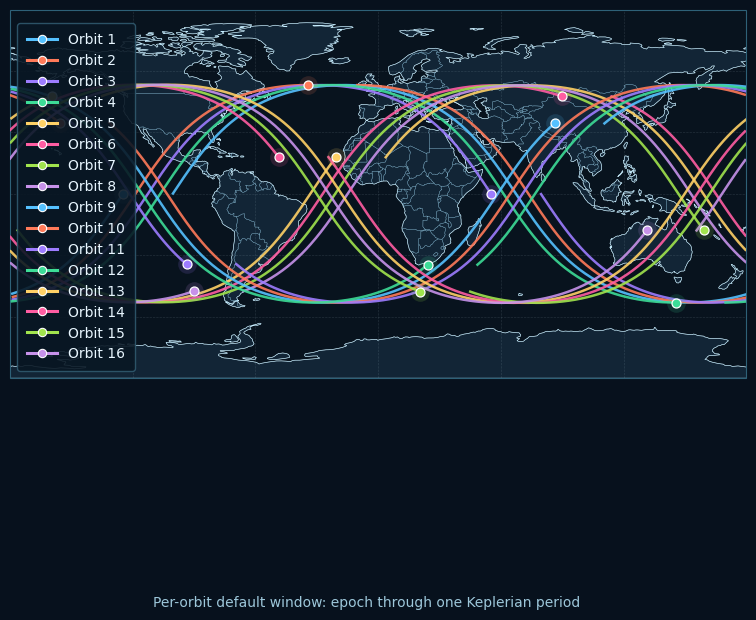

satellites: 16
time samples: 481
targets: 41367
interval_count: 3931081
plot-ready surface grid metadata: True


In [4]:
epoch = Time("2026-01-01T00:00:00", scale="utc")
seed = Orbit.from_kepler_two_body(
    epoch=epoch,
    a=7000e3,
    e=0.000,
    i=np.deg2rad(53.0),
    raan=0.0,
    argp=0.0,
    anomaly=0.0,
    anomaly_type="mean",
)

sats = build_walker_constellation(
    seed,
    total_satellites=16,
    num_planes=4,
    phasing=1,
    pattern="delta",
    include_seed=True,
)

duration_s = 86400 * 1
step_s = 180.0
times = epoch + np.arange(0.0, duration_s + step_s, step_s, dtype=np.float64) * u.s
t_seconds = (times - times[0]).to_value(u.s).astype(np.float64)

config = ExactCoverageConfig(
    nlats=181,
    nlons_equator=361,
    scale_longitude_by_latitude=True,
    min_lon_points_per_row=1,
    min_elevation_deg=0.0,
    max_elevation_deg=90.0,
    include_lat_endpoints=True,
    include_lon_endpoints=False,
)

plot_orbits(sats, view='2d')
observer_positions = [sat.get_p_np(times, frame="itrf") for sat in sats]
store = compute_access_intervals(
    config=config,
    time=t_seconds,
    observer_positions=observer_positions,
    interpolation="cubic",
    root_tolerance_s=1e-3,
)

print(f"satellites: {len(sats)}")
print(f"time samples: {times.size}")
print(f"targets: {store.n_targets}")
print(f"interval_count: {store.start_times.size}")
print(f"plot-ready surface grid metadata: {store.has_surface_target_grid()}")

## 2) Availability Map

`plot_interval_access_duration(...)` computes the metric and plots it directly on your `nstk.plotting` basemap preset.

(<Figure size 1440x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Availability: Access Duration (N>=1)'}>,
 <matplotlib.colorbar.Colorbar at 0x13821d6a0>)

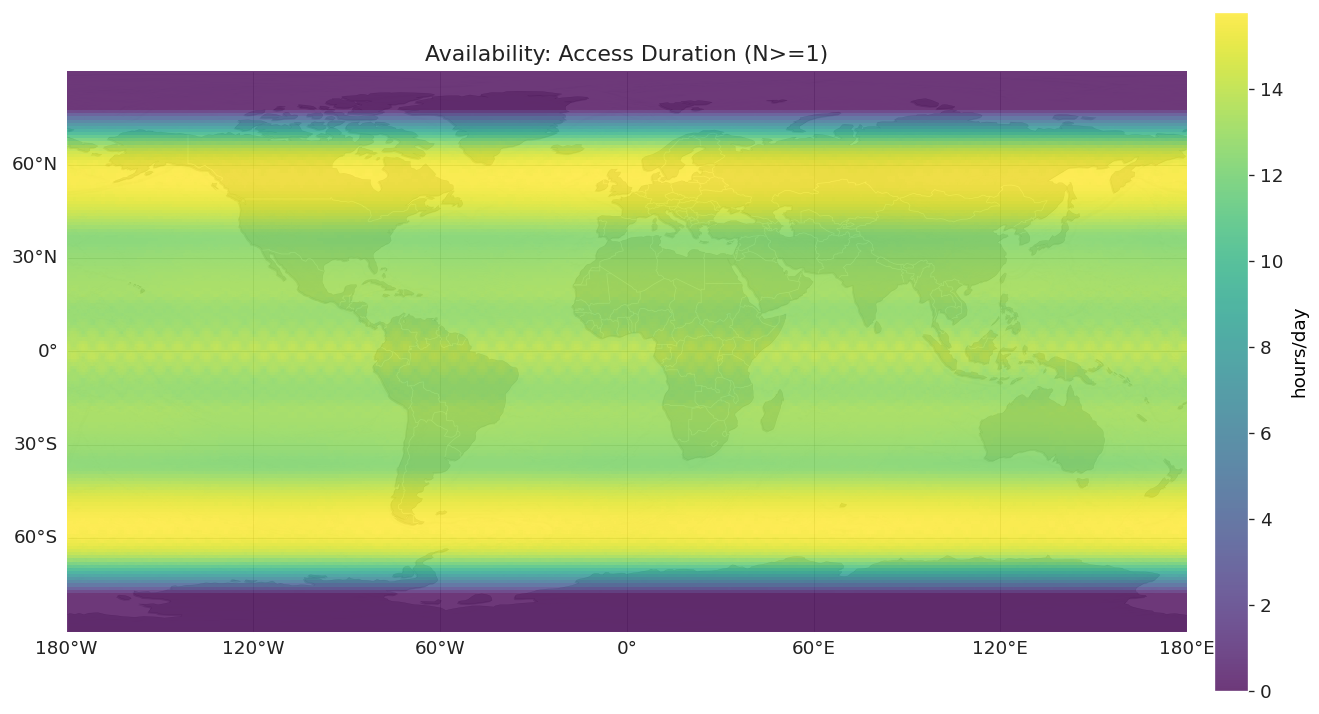

In [5]:
plot_interval_access_duration(
    store,
    N=1,
    normalize_to_day=True,
    unit="hours",
    map_cfg=LIGHT_DETAILED,
    title="Availability: Access Duration (N>=1)",
)

## 3) Redundancy And Peak Overlap

The same store can be scored for stricter coverage requirements and concurrency metrics.

(<Figure size 1440x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Redundancy: Access Duration (N>=2)'}>,
 <matplotlib.colorbar.Colorbar at 0x1383ad940>)

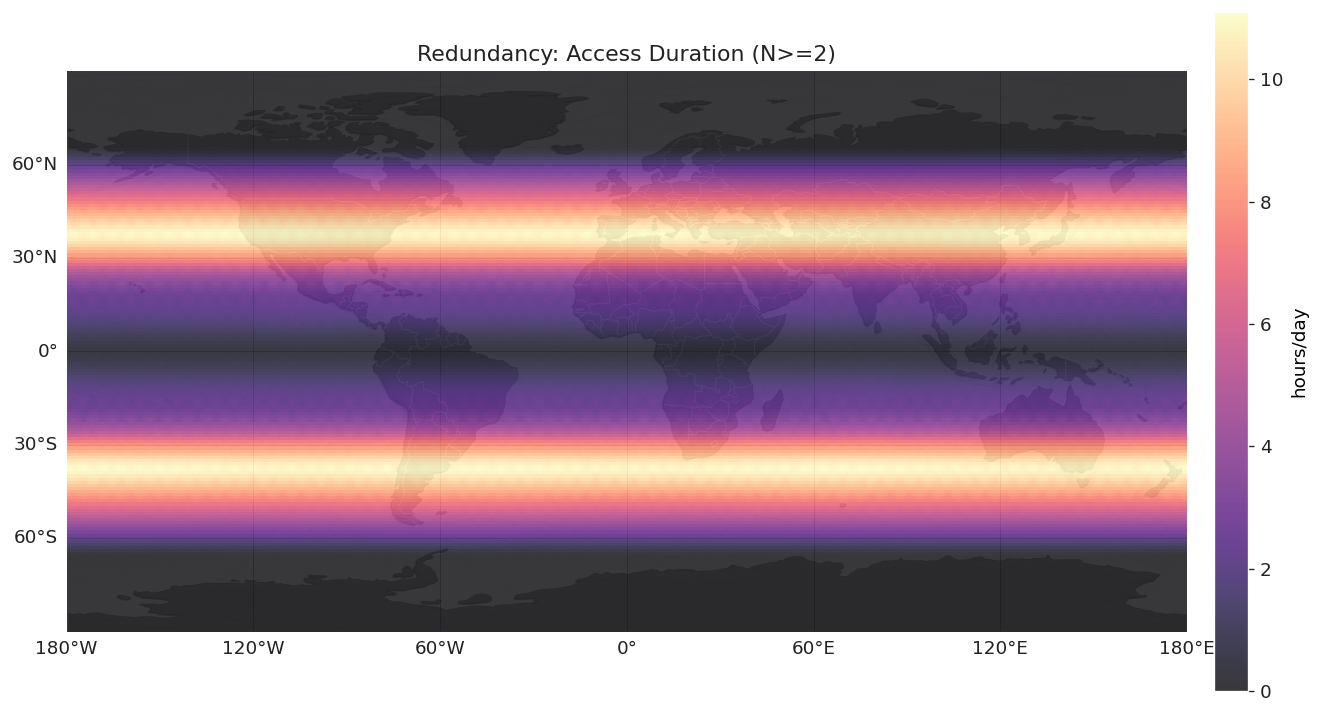

In [6]:
plot_interval_access_duration(
    store,
    N=2,
    normalize_to_day=True,
    unit="hours",
    map_cfg=LIGHT_DETAILED,
    title="Redundancy: Access Duration (N>=2)",
    cmap="magma",
)

(<Figure size 1440x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Peak Overlap: Maximum Concurrent Observers'}>,
 <matplotlib.colorbar.Colorbar at 0x138455400>)

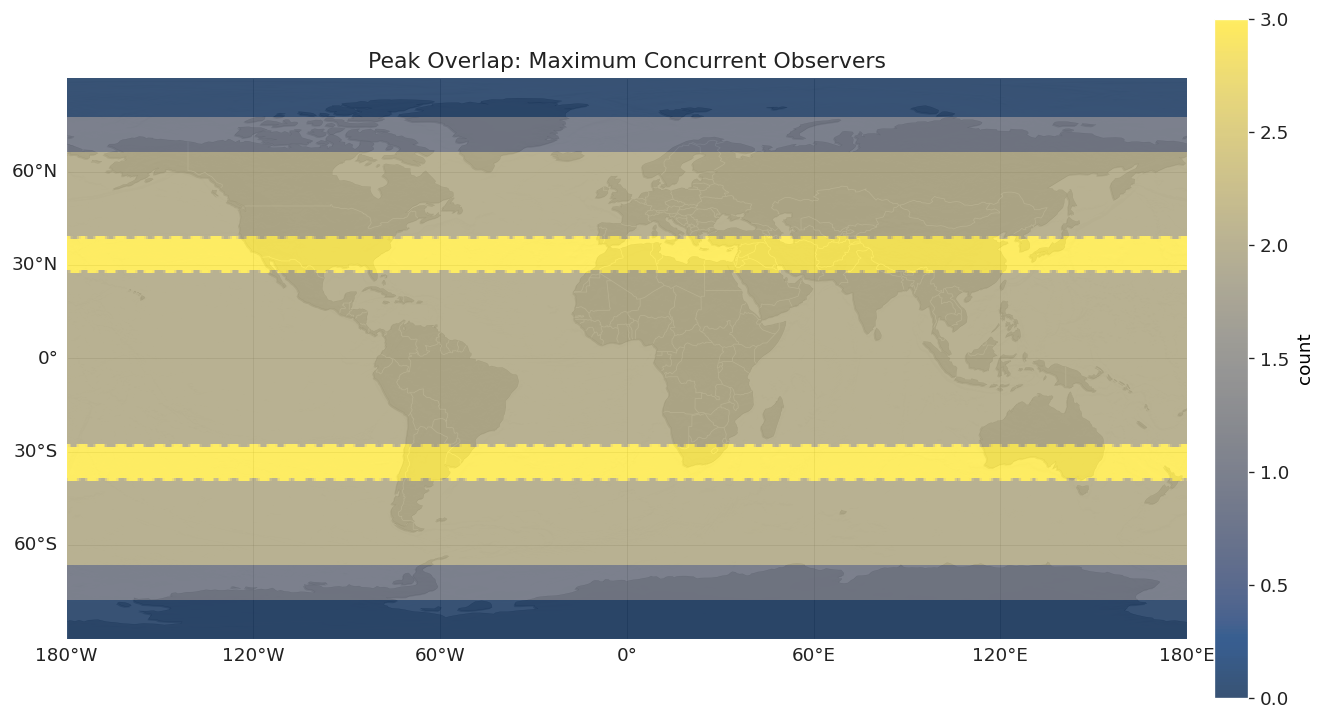

In [7]:
plot_interval_max_asset(
    store,
    map_cfg=LIGHT_DETAILED,
    title="Peak Overlap: Maximum Concurrent Observers",
    cmap="cividis",
)

## 4) Responsiveness Metrics

Interval coverage is especially useful when you want timing-based figures of merit such as MTTA or revisit behavior.

(<Figure size 1440x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Responsiveness: Mean Time To Access'}>,
 <matplotlib.colorbar.Colorbar at 0x13855d010>)

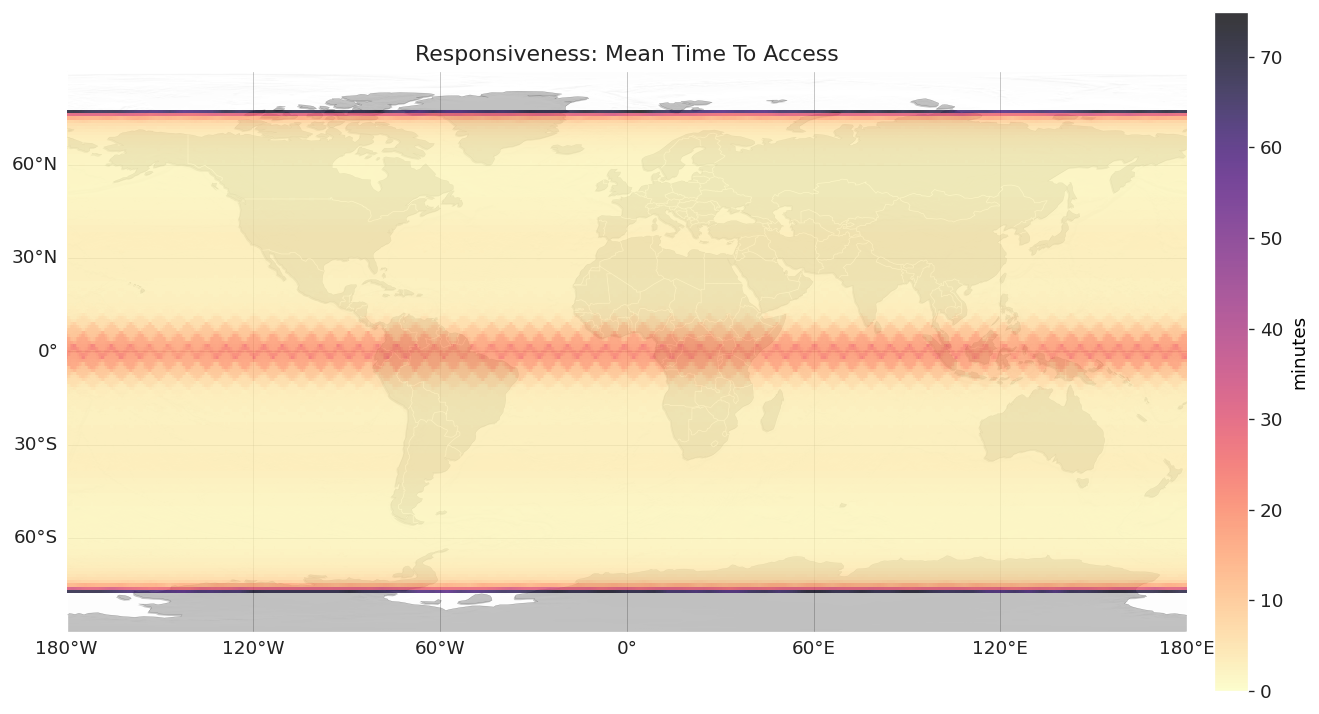

In [8]:
plot_interval_mtta(
    store,
    N=1,
    wrap=False,
    unit="minutes",
    map_cfg=LIGHT_DETAILED,
    title="Responsiveness: Mean Time To Access",
    cmap="magma_r",
)

(<Figure size 1440x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Worst Revisit Gap'}>,
 <matplotlib.colorbar.Colorbar at 0x1385fd160>)

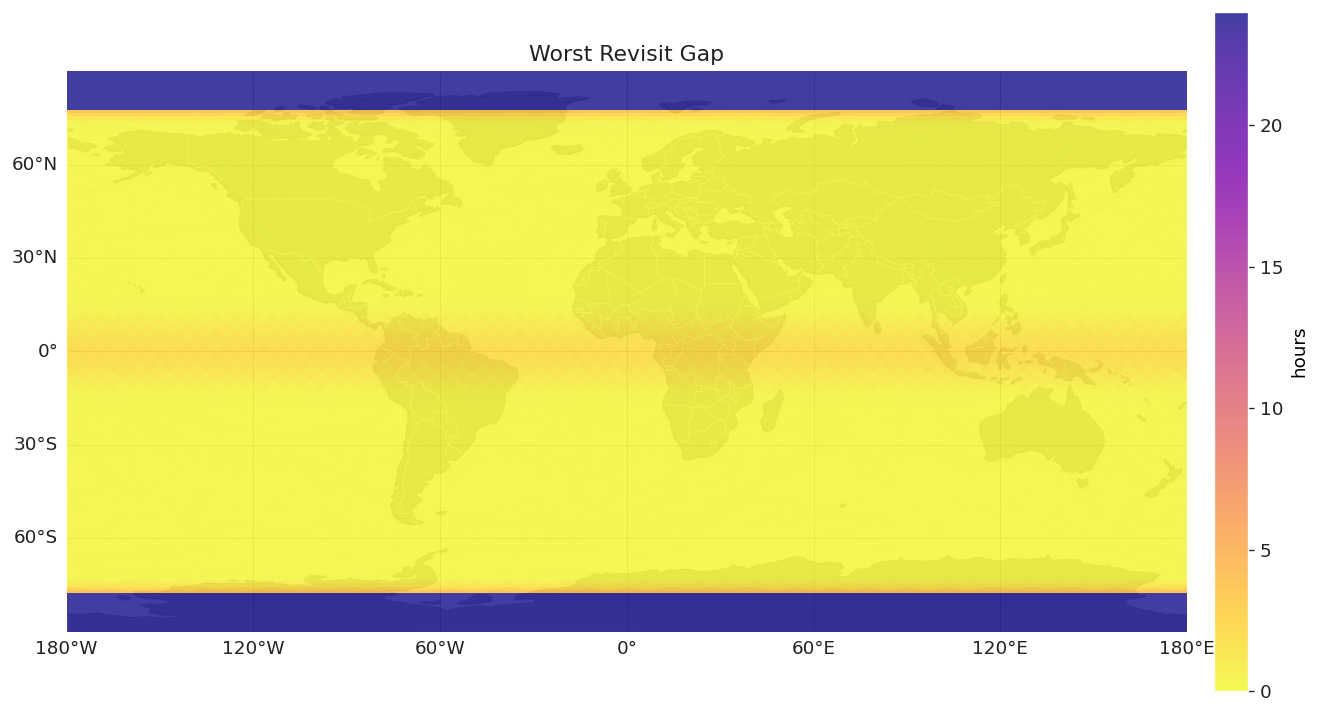

In [9]:
plot_interval_revisit_time(
    store,
    N=1,
    option="maximum",
    end_gaps="include",
    unit="hours",
    map_cfg=LIGHT_DETAILED,
    title="Worst Revisit Gap",
    cmap="plasma_r",
)

## 5) Exact Target Timeline

We can also inspect the exact per-satellite access intervals for a specific target without writing any notebook-side interval parsing.

(<Figure size 1440x780 with 2 Axes>,
 (<Axes: title={'center': 'Exact Access Intervals for London (target at 51.00 deg, 0.00 deg)'}, ylabel='Observer'>,
  <Axes: xlabel='Time [hours]', ylabel='Concurrent\nobservers'>))

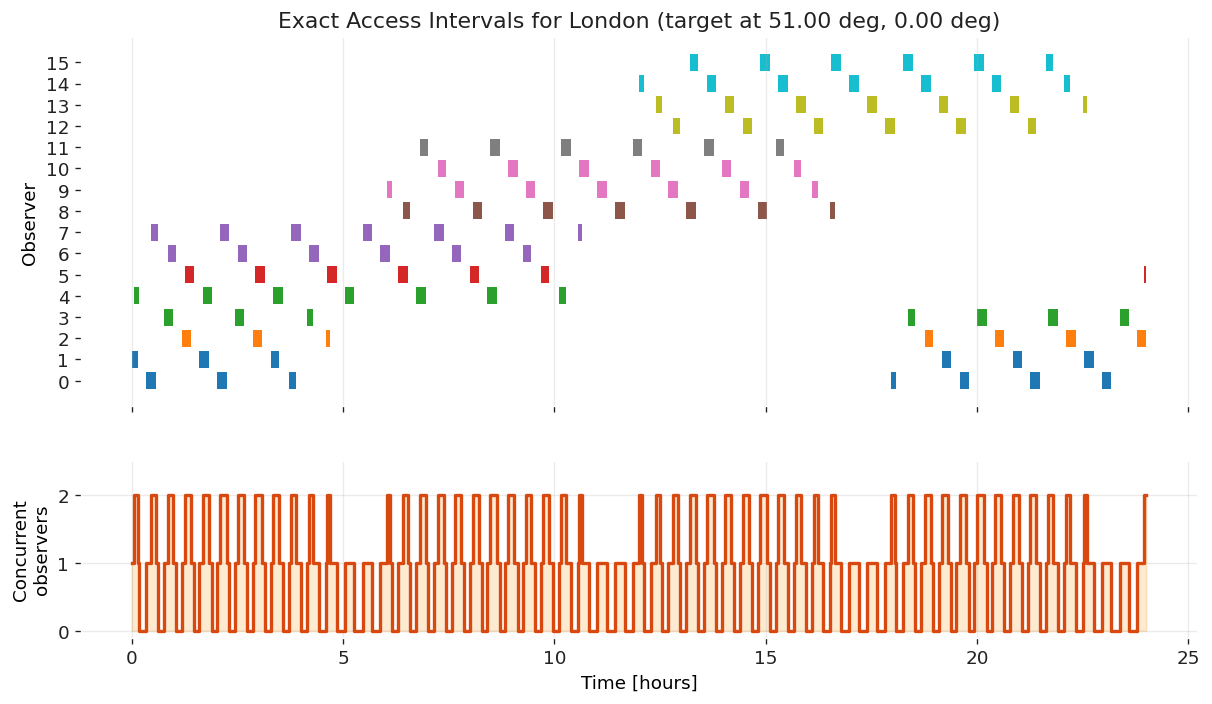

In [10]:
plot_interval_target_timeline(
    store,
    lat_deg=51.51,
    lon_deg=-0.13,
    target_name="London",
)

## 6) Re-Score A Shorter Mission Window

The exact interval store is reusable. We can evaluate a different mission window directly from the same stored intervals.

(<Figure size 1440x720 with 2 Axes>,
 <GeoAxes: title={'center': 'First 6 Hours: Access Duration (N>=1)'}>,
 <matplotlib.colorbar.Colorbar at 0x1387aaf90>)

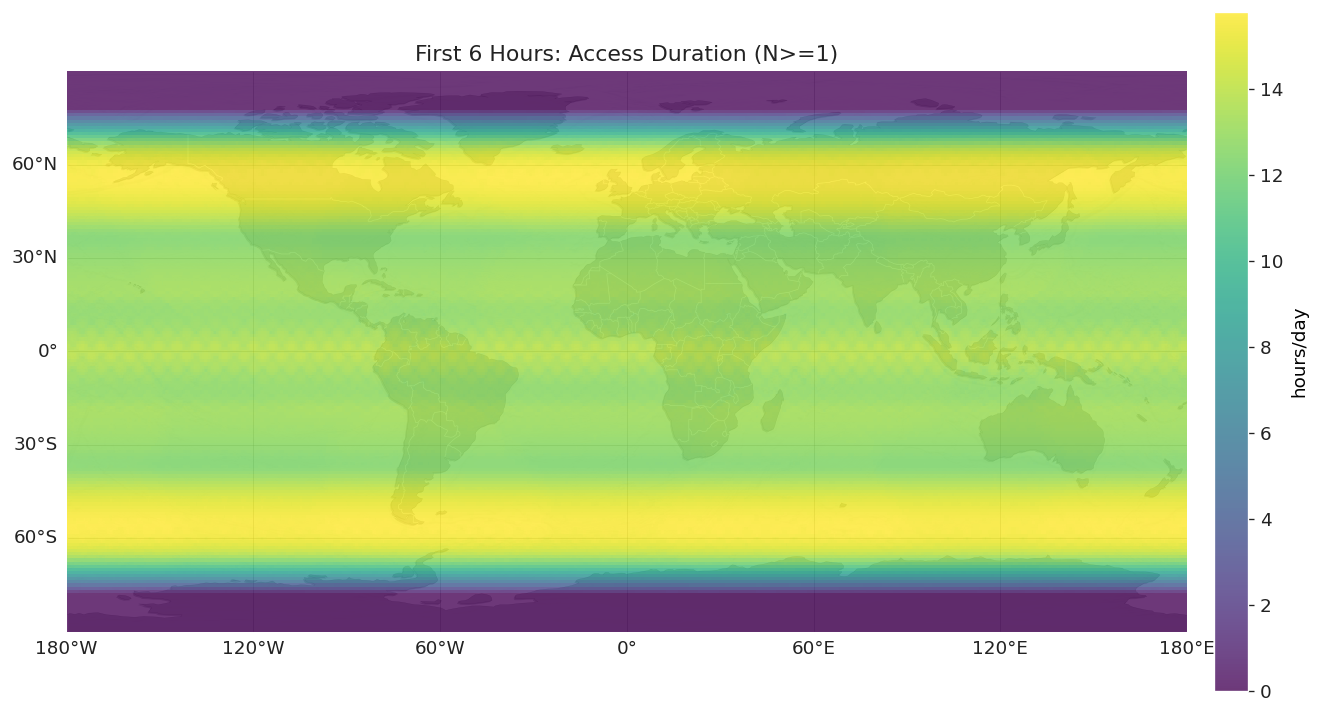

In [11]:
plot_interval_access_duration(
    store,
    N=1,
    t_start=0.0,
    t_stop=6.0 * 3600.0,
    normalize_to_day=True,
    unit="hours",
    map_cfg=LIGHT_DETAILED,
    title="First 6 Hours: Access Duration (N>=1)",
)

## What This Notebook Demonstrated

The important part of this example is the interface:
- `compute_access_intervals(...)` builds one exact interval store
- the plotting API in `nstk.plotting` consumes that store directly
- the same store can drive availability, redundancy, MTTA, revisit, and exact target-timeline views
- shorter mission windows can be re-scored without rebuilding the geometry